In [1]:
#%config InlineBackend.figure_formats=['svg']
import numpy as np
from os import listdir
import matplotlib.pyplot as plt

In [2]:
from AutoencoderAPI.autoencoderKernelDensity import autoencoder_kernelDensity
from AutoencoderAPI.utils.correlation import second_order
from ExistingAlgorithms.Plot import plot_traces

## NIST dataset

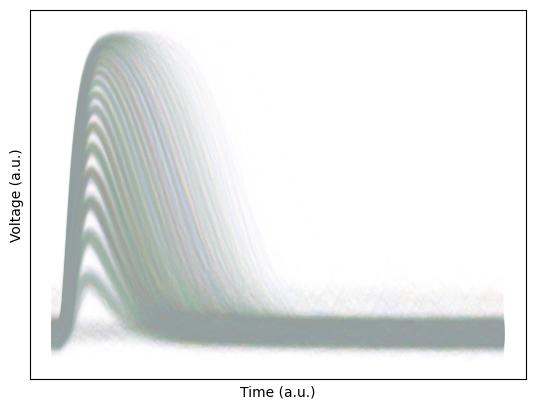

(143360, 250)

In [3]:
signal_size = 250
coherent_29 = 'Datasets/NIST (250) 29dB/'
coherent_28_5 = 'Datasets/NIST (250) 28.5dB/'
coherent_28 = 'Datasets/NIST (250) 28dB/'
path_test = 'Datasets/NIST (250) test/'
path_train = 'Datasets/NIST (250) train/'

X_coherent_29 = np.concatenate([np.fromfile(f"{coherent_29}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_29)])
X_coherent_29 = X_coherent_29.astype("double")

X_coherent_28_5 = np.concatenate([np.fromfile(f"{coherent_28_5}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_28_5)])
X_coherent_28_5 = X_coherent_28_5.astype("double")

X_coherent_28 = np.concatenate([np.fromfile(f"{coherent_28}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(coherent_28)])
X_coherent_28 = X_coherent_28.astype("double")

X_test = np.concatenate([np.fromfile(f"{path_test}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_test)])
X_test = X_test.astype("double")

X_train = np.concatenate([np.fromfile(f"{path_train}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(path_train)])
X_train = X_train.astype("double")

X = np.concatenate((X_test,X_train))

plot_traces(X)
np.shape(X)

### Autoencoder

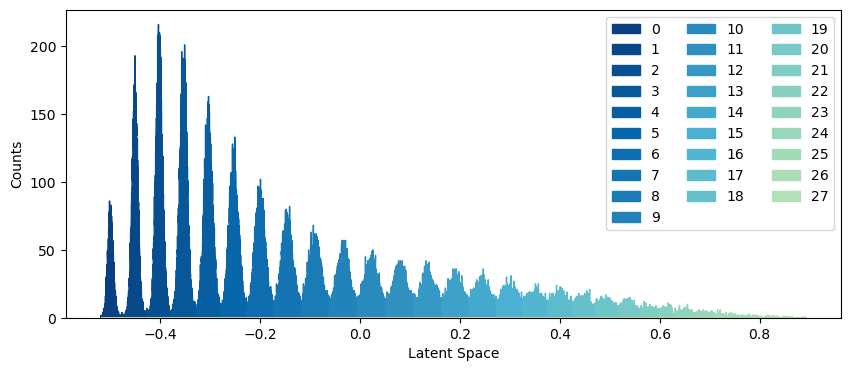

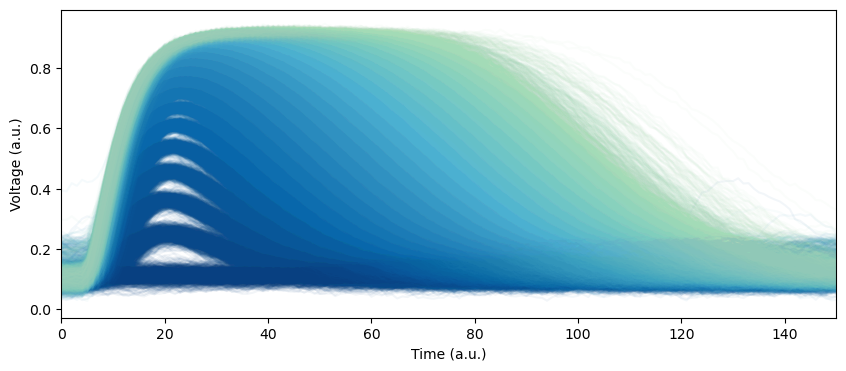

In [4]:
kd = autoencoder_kernelDensity("AutoencoderLog/run-2023-10-10-09-19/fold 0")
kd.fit(X, bw_cst=[0.008], plot_density=False, plot_cluster=True, plot_traces=True, traces_xlim=(0,150))

### 29dB Attenuation (Coherent state)

Second order correlation :  1.0050638499018634
Average photon number :  2.005908203125
Number of traces :  20480


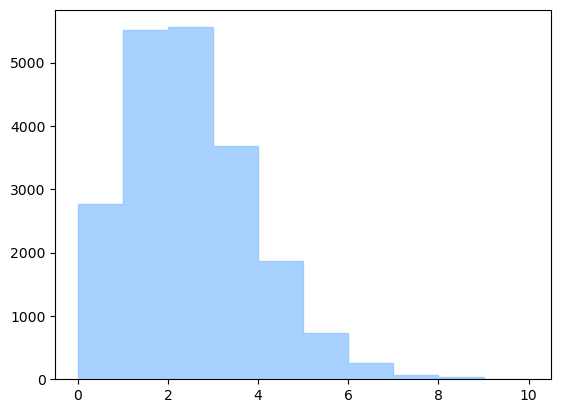

In [8]:
labels_29 = np.array(kd.get_label(X_coherent_29))
g2_29 = second_order(labels_29)
#labels_29 = labels_29[labels_29 != 0]

print("Second order correlation : ", g2_29)
print("Average photon number : ", np.mean(labels_29))
print("Number of traces : ", len(labels_29))

plt.figure()
plt.hist(labels_29, alpha = 0.8, fill=True, histtype='step')
plt.show()

### 28.5dB Attenuation (Coherent state)

Second order correlation :  1.0102209518569216
Average photon number :  2.86533203125
Number of traces :  20480


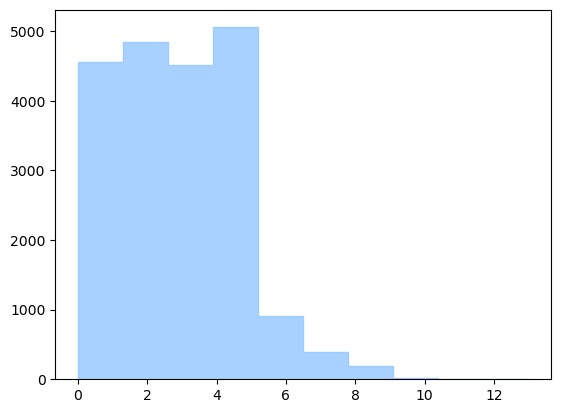

In [ ]:
labels_28_5 = kd.get_label(X_coherent_28_5)
g2_28_5 = second_order(labels_28_5)

print("Second order correlation : ", g2_28_5)
print("Average photon number : ", np.mean(labels_28_5))
print("Number of traces : ", len(labels_28_5))

plt.figure()
plt.hist(labels_28_5, alpha = 0.8, fill=True, histtype='step')
plt.show()

### 28dB Attenuation (Coherent state)

Second order correlation :  0.9964658842626439
Average photon number :  4.017041015625
Number of traces :  20480


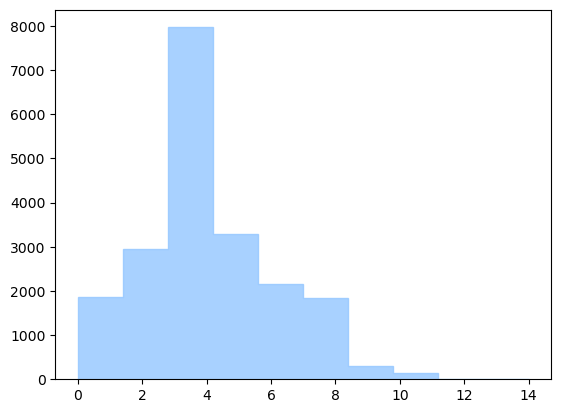

In [ ]:
labels_28 = kd.get_label(X_coherent_28)
g2_28 = second_order(labels_28)

print("Second order correlation : ", g2_28)
print("Average photon number : ", np.mean(labels_28))
print("Number of traces : ", len(labels_28))

plt.figure()
plt.hist(labels_28, alpha = 0.8, fill=True, histtype='step')
plt.show()

### 26dB - 29dB Attenuation (Multiple coherent state)

Second order correlation :  1.425650719992703
Average photon number :  7.091378348214286
Number of traces :  143360


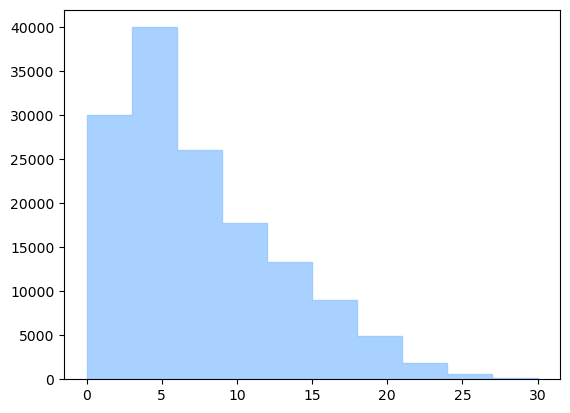

In [ ]:
labels_tot = kd.get_label(X)
g2_tot = second_order(labels_tot)

print("Second order correlation : ", g2_tot)
print("Average photon number : ", np.mean(labels_tot))
print("Number of traces : ", len(labels_tot))

plt.figure()
plt.hist(labels_tot, alpha = 0.8, fill=True, histtype='step')
plt.show()

## Oxford dataset (Thermal state)

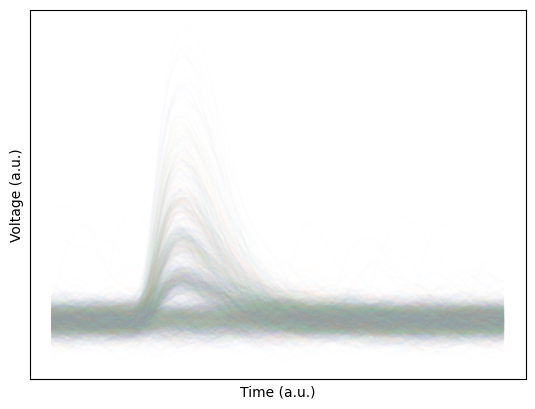

In [ ]:
signal_size = 496
Oxford = 'Datasets/Oxford/'

X_Oxford = np.concatenate([np.fromfile(f"{Oxford}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(Oxford)])
X_Oxford = X_Oxford.astype("double")

plot_traces(X_Oxford)

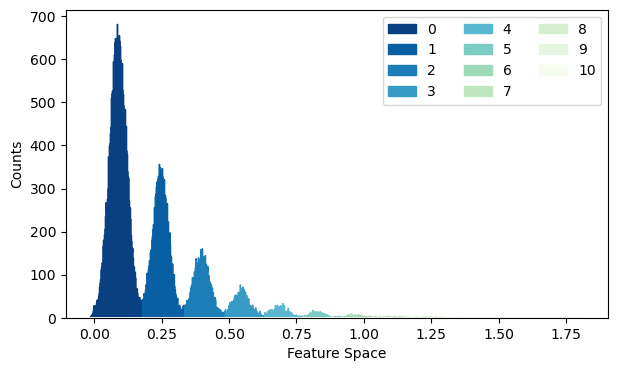

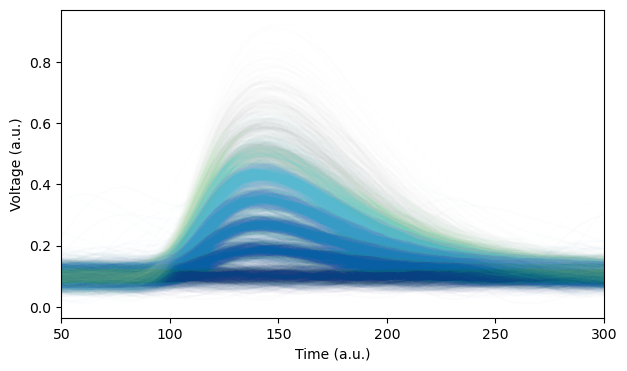

In [ ]:
kd = autoencoder_kerneDensity("Autoencoder Log/run-2023-09-05-22-12/fold 0")
kd.fit_cluster(X_Oxford, plot_density=False, plot_cluster=True, plot_traces=True, traces_xlim=(50,300))

Second order correlation :  1.8331675929201907
Average photon number :  0.78515625
Number of traces :  52224


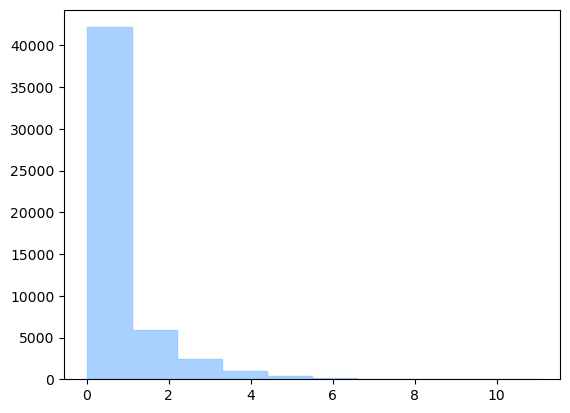

In [ ]:
labels_ox = kd.get_label(X_Oxford)
g2_ox = second_order(labels_ox)

print("Second order correlation : ", g2_ox)
print("Average photon number : ", np.mean(labels_ox))
print("Number of traces : ", len(labels_ox))

plt.figure()
plt.hist(labels_ox, alpha = 0.8, fill=True, histtype='step')
plt.show()

## NIST PIKA (Coherent state)

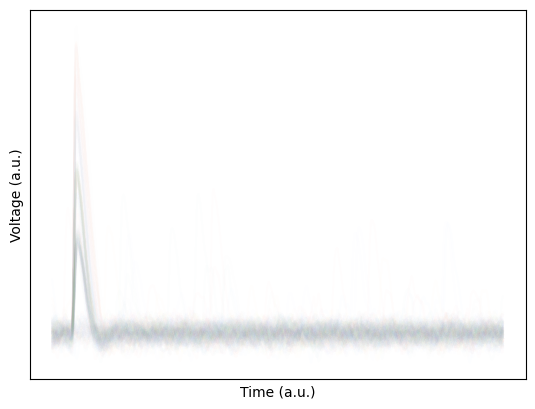

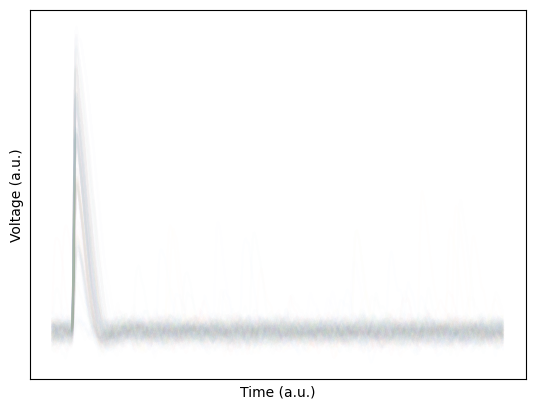

In [ ]:
signal_size = 4096
PIKA1 = 'Datasets/NIST PIKA 1 (4096)/'
PIKA2 = 'Datasets/NIST PIKA 2 (4096)/'

X_PIKA1 = np.concatenate([np.fromfile(f"{PIKA1}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(PIKA1)])
X_PIKA1 = X_PIKA1.astype("double")

X_PIKA2 = np.concatenate([np.fromfile(f"{PIKA2}{fileName}",dtype=np.float16).reshape(-1,signal_size) for fileName in listdir(PIKA2)])
X_PIKA2 = X_PIKA2.astype("double")

plot_traces(np.copy(X_PIKA1))
plot_traces(np.copy(X_PIKA2))

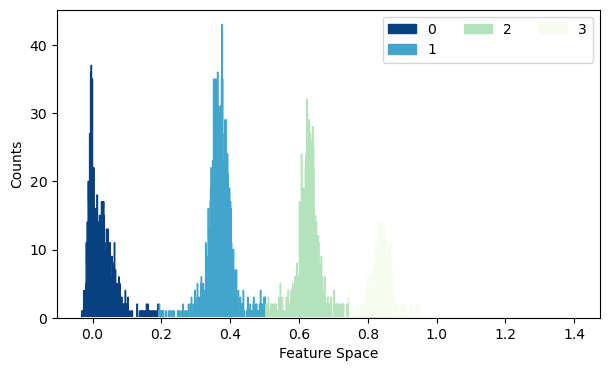

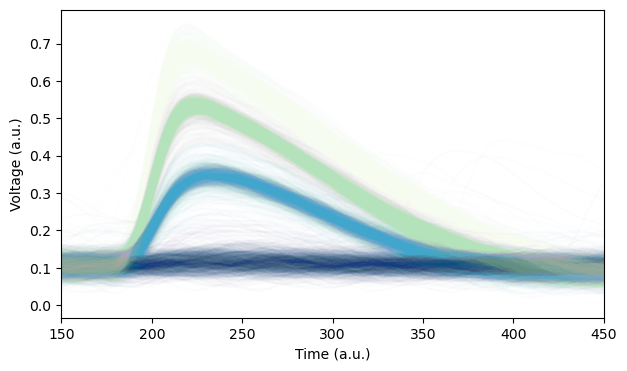

In [ ]:
kd = autoencoder_kerneDensity("Autoencoder Log/run-2023-09-14-08-06/fold 0")
kd.fit_cluster(X_PIKA1, plot_density=False, plot_cluster=True, plot_traces=True, traces_xlim=(150,450))

Second order correlation :  0.9424936918365925
Average photon number :  1.45849609375
Number of traces :  4096


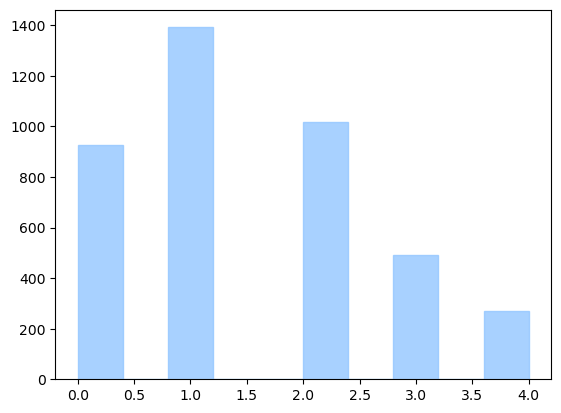

In [ ]:
labels_PIKA1 = kd.get_label(X_PIKA1)
g2_PIKA1 = second_order(labels_PIKA1)

print("Second order correlation : ", g2_PIKA1)
print("Average photon number : ", np.mean(labels_PIKA1))
print("Number of traces : ", len(labels_PIKA1))

plt.figure()
plt.hist(labels_PIKA1, alpha = 0.8, fill=True, histtype='step')
plt.show()

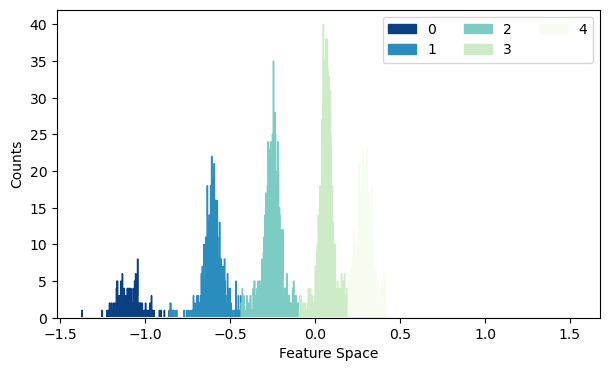

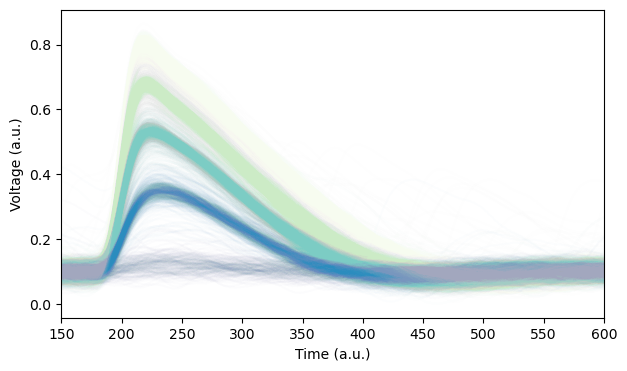

In [ ]:
kd = autoencoder_kerneDensity("Autoencoder Log/run-2023-09-14-08-12/fold 0")
kd.fit_cluster(X_PIKA2, plot_density=False, plot_cluster=True, plot_traces=True, bw_cst=3, flip=True, traces_xlim=(150,600))

Second order correlation :  0.9070833205557778
Average photon number :  2.92041015625
Number of traces :  4096


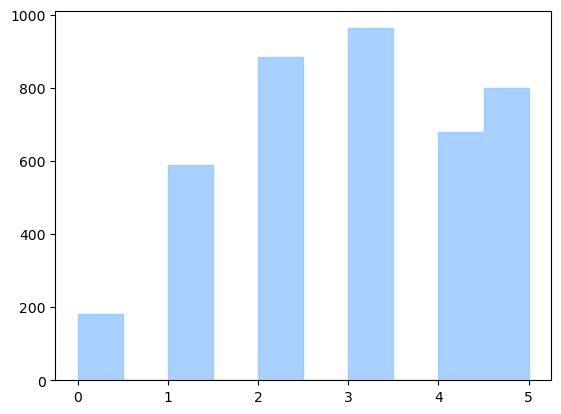

In [ ]:
labels_PIKA2 = kd.get_label(X_PIKA2)
g2_PIKA2 = second_order(labels_PIKA2)

print("Second order correlation : ", g2_PIKA2)
print("Average photon number : ", np.mean(labels_PIKA2))
print("Number of traces : ", len(labels_PIKA2))

plt.figure()
plt.hist(labels_PIKA2, alpha = 0.8, fill=True, histtype='step')
plt.show()